
# 01 — Data Science Introduction

### A complete, self-contained beginner's notebook

This notebook is written so that **you don't need to open any other file, website, or resource** to follow along.
Every term is explained in plain English, every piece of code is shown with its real output, and every section builds on the one before it.

---

## What is Data Science?

**Data Science** is the field of studying data to find patterns, answer questions, and make decisions.

Think of it like being a detective:
- You collect **clues** (data)
- You organize them (**cleaning**)
- You look for patterns (**analysis**)
- You explain what you found using pictures (**visualization**)
- You use it to predict or decide something (**insights**)

A Data Scientist mainly uses **Python** with two core libraries:

| Library | What it does | Real-life comparison |
|---|---|---|
| **NumPy** | Fast math on numbers/lists | A super-calculator |
| **Pandas** | Working with tables of data | A programmable Excel sheet |

---

## What this notebook covers

1. Arrays & NumPy basics
2. Pandas Series & DataFrames
3. Exploring a dataset
4. Selecting, slicing & filtering data
5. Handling missing data (NaN)
6. Descriptive statistics (mean, median, mode, std)
7. GroupBy
8. Sorting, duplicates & unique values
9. Merging / joining tables
10. Pivot tables
11. Reading & writing CSV files
12. Data visualization
13. Quick-reference glossary
14. Practice exercises

Every code cell has already been **run**, so you can see the real output directly under it — no need to run anything yourself unless you want to experiment.



## 🔧 Setup

We start by importing the two most important libraries in data science:

- `numpy` → for fast math and arrays
- `pandas` → for tables of data (DataFrames)
- `matplotlib` → for charts and graphs

> **Library** = a collection of pre-written code you can reuse, so you don't build everything from scratch.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes our charts appear directly inside the notebook
%matplotlib inline

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Setup complete! ✅")


NumPy version: 2.4.4
Pandas version: 3.0.2
Setup complete! ✅



---
## 1️⃣ Arrays & NumPy

### What is an Array?
An **Array** is a list of items (usually numbers), all of the same type, stored together.

> 🧠 *Real-life example: A row of lockers numbered 1–10, each holding one item — that's like an array.*

### What is NumPy?
**NumPy** is a Python library built specifically to work with arrays quickly and efficiently.


In [2]:

# Creating a simple NumPy array of exam scores
scores = np.array([85, 90, 76, 60, 95, 88, 72])
print("Scores array:", scores)
print("Type:", type(scores))


Scores array: [85 90 76 60 95 88 72]
Type: <class 'numpy.ndarray'>



### Dimension & Shape

- **Dimension** = how many directions the data extends in (1D = a list, 2D = a table, 3D = a cube of tables)
- **Shape** = the size of the data in terms of rows and columns

> 🧠 *A single row of numbers is 1D. A full spreadsheet with rows and columns is 2D.*


In [3]:

# 1D array (a simple list of numbers)
one_d = np.array([1, 2, 3, 4])
print("1D array:", one_d)
print("Shape:", one_d.shape, "| Dimensions:", one_d.ndim)

print()

# 2D array (like a mini table: 2 rows, 3 columns)
two_d = np.array([[1, 2, 3],
                   [4, 5, 6]])
print("2D array:\n", two_d)
print("Shape:", two_d.shape, "| Dimensions:", two_d.ndim)


1D array: [1 2 3 4]
Shape: (4,) | Dimensions: 1

2D array:
 [[1 2 3]
 [4 5 6]]
Shape: (2, 3) | Dimensions: 2



### Vectorization & Broadcasting

- **Vectorization** = doing math on an *entire* array at once instead of looping item by item (much faster).
- **Broadcasting** = a NumPy trick that lets you do math on arrays of *different sizes* without writing loops.

> 🧠 *If every student gets 5 bonus marks, you don't add it one student at a time — broadcasting adds it to everyone instantly.*


In [4]:

scores = np.array([85, 90, 76, 60, 95])

# Vectorization: add 5 bonus marks to EVERY score at once (no loop needed!)
bonus_scores = scores + 5
print("Original scores:", scores)
print("Scores with bonus (vectorized):", bonus_scores)

# Broadcasting: multiply every score by a single number
scaled_scores = scores * 1.1   # e.g. 10% grading curve
print("Scores after 10% curve (broadcasting):", scaled_scores)


Original scores: [85 90 76 60 95]
Scores with bonus (vectorized): [ 90  95  81  65 100]
Scores after 10% curve (broadcasting): [ 93.5  99.   83.6  66.  104.5]



### Array Slicing

**Slice** = taking a smaller piece out of an array or list.

> 🧠 *Picking only the first 3 students from a class list of 30.*


In [5]:

scores = np.array([85, 90, 76, 60, 95, 88, 72])

first_three = scores[0:3]      # first 3 scores
last_two    = scores[-2:]      # last 2 scores

print("All scores:", scores)
print("First three (slice):", first_three)
print("Last two (slice):", last_two)


All scores: [85 90 76 60 95 88 72]
First three (slice): [85 90 76]
Last two (slice): [88 72]



---
## 2️⃣ Pandas: Series & DataFrames

### What is Pandas?
**Pandas** is a Python library for working with tables of data — like Excel, but controlled with code.

### Series vs DataFrame

| Term | Definition | Real-life example |
|---|---|---|
| **Series** | A single column of data with labels | Just the "Marks" column on its own |
| **DataFrame** | A full table with rows and columns | An entire class record sheet |


In [6]:

# --- A Pandas Series (single column) ---
marks_series = pd.Series([85, 90, 76, 60, 95], name="Marks")
print("A Pandas Series:")
print(marks_series)
print("\nType:", type(marks_series))


A Pandas Series:
0    85
1    90
2    76
3    60
4    95
Name: Marks, dtype: int64

Type: <class 'pandas.Series'>



### Creating a DataFrame

Let's build a small **Dataset** (a collection of related data) about students — this will be our example table for the rest of the notebook.

- **Data** = the raw facts/numbers themselves (names, ages, marks)
- **Feature** = a single measurable property/column (e.g. "Age", "Marks" are each a feature)
- **Column** = a vertical set of values (e.g. all the ages)
- **Row** = a horizontal set of values, i.e. one full record (e.g. one student's full info)


In [7]:

data = {
    "Name":  ["Ali", "Sara", "Zain", "Mina", "Bilal", "Hina", "Omar", "Noor"],
    "Age":   [20, 21, 19, 22, 20, 23, 21, np.nan],          # np.nan = a missing value
    "City":  ["Lahore", "Karachi", "Lahore", "Islamabad", "Karachi", "Lahore", "Multan", "Karachi"],
    "Marks": [85, 90, 76, 60, 95, 88, 72, 81]
}

df = pd.DataFrame(data)
df


,Name,Age,City,Marks
0,Ali,20.0,Lahore,85
1,Sara,21.0,Karachi,90
2,Zain,19.0,Lahore,76
3,Mina,22.0,Islamabad,60
4,Bilal,20.0,Karachi,95
5,Hina,23.0,Lahore,88
6,Omar,21.0,Multan,72
7,Noor,NaN,Karachi,81



---
## 3️⃣ Exploring a Dataset

Before doing any analysis, always look at your data first.

- **Head** = viewing just the first few rows of a dataset
- **Shape** = size of data in (rows, columns)
- **Index** = the row labels
- **Data Type** = what kind of value each column holds (number, text, etc.)


In [8]:

print("First 3 rows (head):")
display(df.head(3))

print("\nShape of the DataFrame (rows, columns):", df.shape)
print("\nIndex (row labels):", df.index.tolist())
print("\nColumn names:", df.columns.tolist())


First 3 rows (head):


,Name,Age,City,Marks
0,Ali,20.0,Lahore,85
1,Sara,21.0,Karachi,90
2,Zain,19.0,Lahore,76



Shape of the DataFrame (rows, columns): (8, 4)

Index (row labels): [0, 1, 2, 3, 4, 5, 6, 7]

Column names: ['Name', 'Age', 'City', 'Marks']


In [9]:

# Data Type of each column
print("Data types of each column:")
print(df.dtypes)


Data types of each column:
Name         str
Age      float64
City         str
Marks      int64
dtype: object


In [10]:

# A quick statistical + structural summary of the whole DataFrame
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    8 non-null      str    
 1   Age     7 non-null      float64
 2   City    8 non-null      str    
 3   Marks   8 non-null      int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 388.0 bytes



---
## 4️⃣ Selecting, Slicing & Filtering Data

- **Boolean** = a value that is either `True` or `False`
- **Filter** = picking out only the rows that match a certain condition


In [11]:

# Selecting a single column (this returns a Series)
ages = df["Age"]
print("Just the 'Age' column:")
print(ages)


Just the 'Age' column:
0    20.0
1    21.0
2    19.0
3    22.0
4    20.0
5    23.0
6    21.0
7     NaN
Name: Age, dtype: float64


In [12]:

# Slicing rows: first 4 students only
first_four_students = df[0:4]
print("First four students (slice):")
first_four_students


First four students (slice):


,Name,Age,City,Marks
0,Ali,20.0,Lahore,85
1,Sara,21.0,Karachi,90
2,Zain,19.0,Lahore,76
3,Mina,22.0,Islamabad,60


In [13]:

# Boolean condition: which students scored above 80?
above_80 = df["Marks"] > 80
print("Boolean mask (True/False for each row):")
print(above_80)


Boolean mask (True/False for each row):
0     True
1     True
2    False
3    False
4     True
5     True
6    False
7     True
Name: Marks, dtype: bool


In [14]:

# Filter: use the boolean condition to show only matching rows
top_students = df[df["Marks"] > 80]
print("Students who scored above 80 (filtered):")
top_students


Students who scored above 80 (filtered):


,Name,Age,City,Marks
0,Ali,20.0,Lahore,85
1,Sara,21.0,Karachi,90
4,Bilal,20.0,Karachi,95
5,Hina,23.0,Lahore,88
7,Noor,NaN,Karachi,81



---
## 5️⃣ Handling Missing Data (NaN)

**NaN** stands for "Not a Number" — it represents missing or unknown data.

> 🧠 *If a student didn't attend an exam, their score might be recorded as NaN instead of a number.*


In [15]:

# Check which cells are missing
print("Which values are missing (NaN)?")
print(df.isna())


Which values are missing (NaN)?
    Name    Age   City  Marks
0  False  False  False  False
1  False  False  False  False
2  False  False  False  False
3  False  False  False  False
4  False  False  False  False
5  False  False  False  False
6  False  False  False  False
7  False   True  False  False


In [16]:

# Count how many missing values are in each column
print("Number of missing values per column:")
print(df.isna().sum())


Number of missing values per column:
Name     0
Age      1
City     0
Marks    0
dtype: int64


In [17]:

# Fill missing Age with the average age (a common simple fix)
df_filled = df.copy()
df_filled["Age"] = df_filled["Age"].fillna(df_filled["Age"].mean())
print("Age column after filling missing value with the mean:")
df_filled


Age column after filling missing value with the mean:


,Name,Age,City,Marks
0,Ali,20.000000,Lahore,85
1,Sara,21.000000,Karachi,90
2,Zain,19.000000,Lahore,76
3,Mina,22.000000,Islamabad,60
4,Bilal,20.000000,Karachi,95
5,Hina,23.000000,Lahore,88
6,Omar,21.000000,Multan,72
7,Noor,20.857143,Karachi,81



---
## 6️⃣ Descriptive Statistics

| Term | Definition | Example |
|---|---|---|
| **Mean** | The average of a set of numbers | Marks 80, 90, 70 → mean = 80 |
| **Median** | The middle value when sorted | Marks 60, 70, 90 → median = 70 |
| **Mode** | The value that appears most often | Sizes 7, 8, 8, 9 → mode = 8 |
| **Standard Deviation** | How spread out numbers are from the average | Low = scores close together, High = scores vary a lot |


In [18]:

marks = df["Marks"]

print("Mean marks:", marks.mean())
print("Median marks:", marks.median())
print("Mode of marks:", marks.mode()[0])
print("Standard Deviation of marks:", round(marks.std(), 2))


Mean marks: 80.875
Median marks: 83.0
Mode of marks: 60
Standard Deviation of marks: 11.27


In [19]:

# Pandas can also give you ALL key stats in one line
print("Full statistical summary of the Marks column:")
df["Marks"].describe()


Full statistical summary of the Marks column:


count     8.000000
mean     80.875000
std      11.268635
min      60.000000
25%      75.000000
50%      83.000000
75%      88.500000
max      95.000000
Name: Marks, dtype: float64


---
## 7️⃣ GroupBy

**GroupBy** = splitting data into groups based on a value, so you can summarize each group.

> 🧠 *Grouping students by "City" to find the average marks in each city.*


In [20]:

avg_marks_by_city = df.groupby("City")["Marks"].mean()
print("Average marks per city:")
avg_marks_by_city


Average marks per city:


City
Islamabad    60.000000
Karachi      88.666667
Lahore       83.000000
Multan       72.000000
Name: Marks, dtype: float64

In [21]:

# You can also get multiple statistics per group at once
city_summary = df.groupby("City")["Marks"].agg(["mean", "min", "max", "count"])
print("Summary of marks per city:")
city_summary


Summary of marks per city:


,mean,min,max,count
City,,,,
Islamabad,60.000000,60,60,1
Karachi,88.666667,81,95,3
Lahore,83.000000,76,88,3
Multan,72.000000,72,72,1



---
## 8️⃣ Sorting, Duplicates & Unique Values

- **Duplicate** = a row or value that appears more than once
- **Unique** = values that appear only once, with no repeats


In [22]:

# Sort students by marks, highest first
sorted_df = df.sort_values(by="Marks", ascending=False)
print("Students sorted by marks (highest first):")
sorted_df


Students sorted by marks (highest first):


,Name,Age,City,Marks
4,Bilal,20.0,Karachi,95
1,Sara,21.0,Karachi,90
5,Hina,23.0,Lahore,88
0,Ali,20.0,Lahore,85
7,Noor,NaN,Karachi,81
2,Zain,19.0,Lahore,76
6,Omar,21.0,Multan,72
3,Mina,22.0,Islamabad,60


In [23]:

# Unique cities in our dataset
unique_cities = df["City"].unique()
print("Unique cities:", unique_cities)


Unique cities: <StringArray>
['Lahore', 'Karachi', 'Islamabad', 'Multan']
Length: 4, dtype: str


In [24]:

# Checking for duplicate rows
print("Are there any duplicate rows?")
print(df.duplicated().sum(), "duplicate rows found")

# Example: adding a duplicate on purpose to demonstrate
demo_df = pd.concat([df, df.iloc[[0]]], ignore_index=True)  # copy Ali's row again
print("\nAfter adding a duplicate row, duplicates found:", demo_df.duplicated().sum())


Are there any duplicate rows?
0 duplicate rows found

After adding a duplicate row, duplicates found: 1



---
## 9️⃣ Merging / Joining Tables

- **Join** = combining two tables based on a common column
- **Key** = the column used to match rows between tables (must be unique to identify records)

> 🧠 *Merging a "Student Info" table with a "Student Marks" table using the "Roll Number" they both share.*


In [25]:

# Table 1: student info
student_info = pd.DataFrame({
    "RollNo": [1, 2, 3, 4],
    "Name": ["Ali", "Sara", "Zain", "Mina"]
})

# Table 2: student attendance (a different table, joined using RollNo as the key)
attendance = pd.DataFrame({
    "RollNo": [1, 2, 3, 4],
    "AttendancePercent": [95, 88, 76, 99]
})

merged = pd.merge(student_info, attendance, on="RollNo")
print("Merged table (joined using 'RollNo' as the key):")
merged


Merged table (joined using 'RollNo' as the key):

,RollNo,Name,AttendancePercent
0,1,Ali,95
1,2,Sara,88
2,3,Zain,76
3,4,Mina,99



---
## 🔟 Pivot Tables

**Pivot Table** = a table that summarizes and rearranges data to see patterns easily.

> 🧠 *Turning a long list of sales records into a summary showing total sales per city per month.*


In [26]:

pivot = df.pivot_table(values="Marks", index="City", aggfunc="mean")
print("Pivot table — average marks per city:")
pivot


Pivot table — average marks per city:


,Marks
City,
Islamabad,60.000000
Karachi,88.666667
Lahore,83.000000
Multan,72.000000



---
## 1️⃣1️⃣ Reading & Writing CSV Files

**CSV** = "Comma-Separated Values" — a simple text file format where data is separated by commas, like a basic spreadsheet.

Below, we save our DataFrame to a CSV file, then read it back — this is exactly what you'll do with real datasets.


In [27]:

# Save our DataFrame to a CSV file
df.to_csv("students.csv", index=False)
print("Saved to students.csv ✅")

# Read it back from the file
df_from_csv = pd.read_csv("students.csv")
print("\nData read back from CSV file:")
df_from_csv


Saved to students.csv ✅



Data read back from CSV file:


,Name,Age,City,Marks
0,Ali,20.0,Lahore,85
1,Sara,21.0,Karachi,90
2,Zain,19.0,Lahore,76
3,Mina,22.0,Islamabad,60
4,Bilal,20.0,Karachi,95
5,Hina,23.0,Lahore,88
6,Omar,21.0,Multan,72
7,Noor,NaN,Karachi,81



---
## 1️⃣2️⃣ Data Visualization

**Visualization** = turning data into charts/graphs so it's easier to understand.

> 🧠 *Showing student marks as a bar chart instead of a long list of numbers.*


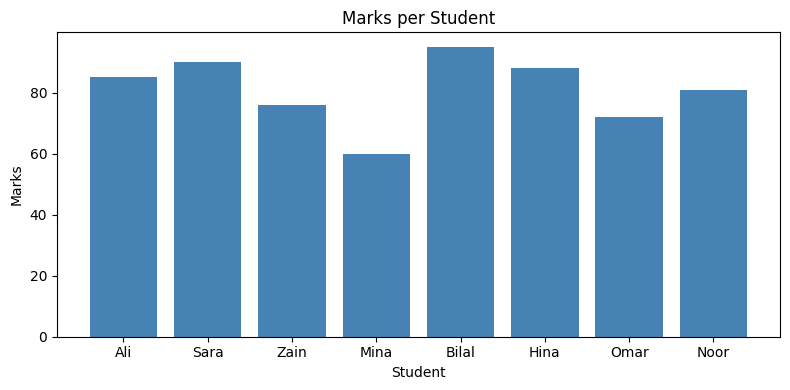

In [28]:

# Bar chart: marks per student
plt.figure(figsize=(8, 4))
plt.bar(df["Name"], df["Marks"], color="steelblue")
plt.title("Marks per Student")
plt.xlabel("Student")
plt.ylabel("Marks")
plt.tight_layout()
plt.show()


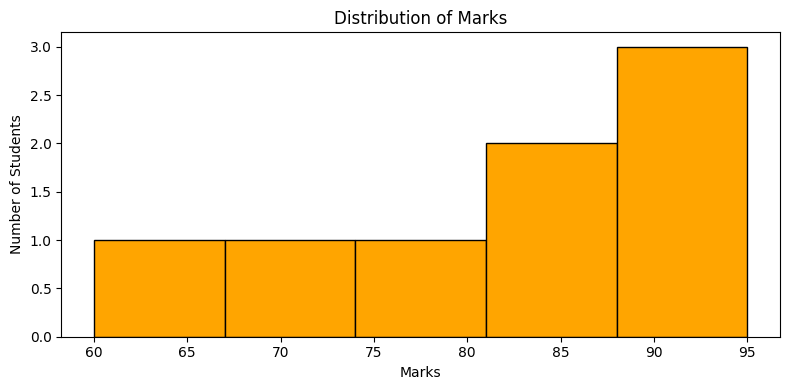

In [29]:

# Histogram: distribution of marks (how spread out they are)
plt.figure(figsize=(8, 4))
plt.hist(df["Marks"], bins=5, color="orange", edgecolor="black")
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


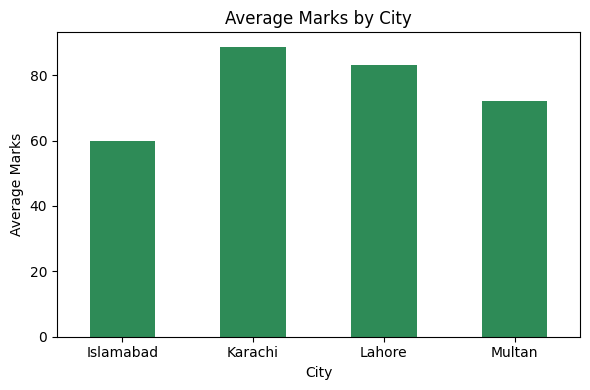

In [30]:

# Bar chart: average marks per city (using our earlier groupby result)
avg_marks_by_city.plot(kind="bar", color="seagreen", figsize=(6, 4))
plt.title("Average Marks by City")
plt.xlabel("City")
plt.ylabel("Average Marks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



---
## 📖 Quick-Reference Glossary Recap

| Term | Simple Definition |
|---|---|
| Algorithm | Step-by-step instructions to solve a problem |
| API | Way for two programs to talk to each other |
| Array | A list of same-type items stored together |
| Axis | Direction of operation: rows or columns |
| Boolean | A True/False value |
| Broadcasting | Doing math on arrays of different sizes automatically |
| Column | A vertical set of values (one feature) |
| CSV | Comma-separated text file format for tables |
| Data | Raw facts or numbers |
| DataFrame | A full table with rows & columns (Pandas) |
| Data Type | The kind of value (number, text, boolean) |
| Dataset | A collection of related data |
| Dimension | How many directions data extends in (1D, 2D, 3D) |
| Duplicate | A row/value that appears more than once |
| Feature | A single measurable column |
| Filter | Selecting rows that match a condition |
| Function | A reusable block of instructions |
| GroupBy | Splitting data into groups to summarize each |
| Head | Viewing the first few rows |
| Index | The row labels |
| Join | Combining two tables using a shared column |
| Key | Column used to match/identify rows |
| Library | Reusable pre-written code |
| Mean | The average |
| Median | The middle value when sorted |
| Mode | The most frequent value |
| NaN | Missing or unknown data |
| NumPy | Library for fast math & arrays |
| Outlier | A value very different from the rest |
| Pandas | Library for working with tables of data |
| Pivot Table | Rearranged summary table |
| Query | A question asked of your data |
| Row | A horizontal set of values (one record) |
| Series | A single labeled column of data |
| Shape | Size of data as (rows, columns) |
| Slice | A smaller piece taken from a list/array |
| Standard Deviation | How spread out values are from the mean |
| Transpose | Flipping rows into columns and vice versa |
| Unique | Values with no repeats |
| Variable | A named container holding a value |
| Vectorization | Doing math on a whole array at once |
| Visualization | Turning data into charts/graphs |



---
## ✏️ Practice Exercises

Try these yourself using the `df` DataFrame we built earlier. Solutions are included — but try first before peeking!

1. Show only the students from "Karachi".
2. Find the highest and lowest marks in the dataset.
3. Sort the DataFrame by "Age" (youngest first).
4. Create a new column called "Pass" that is `True` if Marks >= 75, else `False`.


In [31]:

# 1. Students from Karachi
print("Exercise 1 — Students from Karachi:")
print(df[df["City"] == "Karachi"])


Exercise 1 — Students from Karachi:
    Name   Age     City  Marks
1   Sara  21.0  Karachi     90
4  Bilal  20.0  Karachi     95
7   Noor   NaN  Karachi     81


In [32]:

# 2. Highest and lowest marks
print("Exercise 2 — Highest marks:", df["Marks"].max())
print("Exercise 2 — Lowest marks:", df["Marks"].min())


Exercise 2 — Highest marks: 95
Exercise 2 — Lowest marks: 60


In [33]:

# 3. Sort by Age, youngest first
print("Exercise 3 — Sorted by Age (youngest first):")
print(df.sort_values(by="Age"))


Exercise 3 — Sorted by Age (youngest first):
    Name   Age       City  Marks
2   Zain  19.0     Lahore     76
0    Ali  20.0     Lahore     85
4  Bilal  20.0    Karachi     95
1   Sara  21.0    Karachi     90
6   Omar  21.0     Multan     72
3   Mina  22.0  Islamabad     60
5   Hina  23.0     Lahore     88
7   Noor   NaN    Karachi     81


In [34]:

# 4. New column "Pass" based on a condition
df_exercise = df.copy()
df_exercise["Pass"] = df_exercise["Marks"] >= 75
print("Exercise 4 — Added 'Pass' column:")
df_exercise


Exercise 4 — Added 'Pass' column:


,Name,Age,City,Marks,Pass
0,Ali,20.0,Lahore,85,True
1,Sara,21.0,Karachi,90,True
2,Zain,19.0,Lahore,76,True
3,Mina,22.0,Islamabad,60,False
4,Bilal,20.0,Karachi,95,True
5,Hina,23.0,Lahore,88,True
6,Omar,21.0,Multan,72,False
7,Noor,NaN,Karachi,81,True



---
## 🎯 Conclusion & Next Steps

You've now covered the essential building blocks of Data Science with Python:

✅ Arrays & NumPy
✅ Series & DataFrames
✅ Exploring, selecting, filtering data
✅ Handling missing data
✅ Descriptive statistics
✅ GroupBy, sorting, duplicates, merging, pivot tables
✅ Reading/writing CSV files
✅ Visualization

### What to do next
- Try loading a **real** CSV dataset (e.g. from Kaggle) and repeat these same steps on it.
- Practice by asking your own questions of the data, like "which group has the highest average?" and answering them using the tools above.
- Move on to `02_NumPy.ipynb` (or a similar next notebook) to go deeper into preparing messy real-world data.

**You don't need any other file to understand this notebook — everything was defined, explained, and demonstrated with real output above.**
